 # EfficientNet-B0 Fine-Tuning – ISIC 2018 MEL vs NV

 Binary classification: **MEL** (melanoma) vs **NV** (melanocytic nevi) using the ISIC 2018 Task 3 training set.

 | Detail | Value |
 |---|---|
 | Backbone | EfficientNet-B0 (ImageNet-pretrained) |
 | Input size | 224 × 224 (EfficientNet-B0 default) |
 | Class imbalance | `WeightedRandomSampler` on train split (NV greatly outnumbers MEL) |
 | Checkpointing | Per-epoch, auto-resume from latest `epoch_*.pth` |

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
from collections import defaultdict
import os
import sys
import glob
import math

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler, ConcatDataset
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from datasets import ISIC2018Dataset, TransformDataset
from models import NVMELClassifier

print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

PyTorch 2.6.0+cu124 | CUDA available: False


In [ ]:
# ── Parameters (edit here) ────────────────────────────────────────────────────
TRAIN_ORIG_DATASET_DIR  = "dataset/ISIC_2018/ISIC2018_Task3_Training_Input"
TRAIN_RECON_DATASET_DIR = "dataset/ISIC_2018/ISIC2018_Task3_Training_Input_Recon_MS_SSIM"
TRAIN_LABELS_CSV        = "dataset/ISIC_2018/ISIC2018_Task3_Training_GroundTruth.csv"

VAL_ORIG_DATASET_DIR    = "dataset/ISIC_2018/ISIC2018_Task3_Validation_Input"
VAL_RECON_DATASET_DIR   = "dataset/ISIC_2018/ISIC2018_Task3_Validation_Input_Recon_MS_SSIM"
VAL_LABELS_CSV          = "dataset/ISIC_2018/ISIC2018_Task3_Validation_GroundTruth.csv"

CHECKPOINT_DIR          = "checkpoints/efficientnet_nv_mel_classifier_recon_ms_ssim"

IMAGE_SIZE      = 224          # EfficientNet-B0 default
BATCH_SIZE      = 8
NUM_WORKERS     = 2
LEARNING_RATE   = 1e-4         # lower LR appropriate for fine-tuning
NUM_EPOCHS      = 50
LABEL_SMOOTHING = 0.3          # aggressive label smoothing
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"
LABEL_NAMES     = ["NV", "MEL"]

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Using device  : {DEVICE}")
print(f"Image size    : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Checkpoint dir: {os.path.abspath(CHECKPOINT_DIR)}")

Using device  : cpu
Image size    : 224 x 224
Checkpoint dir: /home/tejas/dev/capstone/checkpoints/efficientnet_nv_mel_classifier_recon_ms_ssim


In [ ]:
# ── Transforms ───────────────────────────────────────────────────────────────
# Train: augmentations to reduce over-fitting on the small MEL class.
# Val  : deterministic centre-crop only.
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                         [0.229, 0.224, 0.225]),   # ImageNet std
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

print("Transform pipelines defined.")

Transform pipelines defined.


In [ ]:
# ── Dataset & DataLoaders ─────────────────────────────────────────────────────

train_orig_dataset = ISIC2018Dataset(
    root_dir       = TRAIN_ORIG_DATASET_DIR,
    transform      = train_transform,
    labels_csv     = TRAIN_LABELS_CSV,
    include_labels = LABEL_NAMES,
)

train_recon_dataset = ISIC2018Dataset(
    root_dir       = TRAIN_RECON_DATASET_DIR,
    transform      = train_transform,
    labels_csv     = TRAIN_LABELS_CSV,
    include_labels = LABEL_NAMES,
)

train_dataset = ConcatDataset([train_orig_dataset, train_recon_dataset])

val_orig_dataset = ISIC2018Dataset(
    root_dir       = VAL_ORIG_DATASET_DIR,
    transform      = val_transform,
    labels_csv     = VAL_LABELS_CSV,
    include_labels = LABEL_NAMES,
)

val_recon_dataset = ISIC2018Dataset(
    root_dir       = VAL_RECON_DATASET_DIR,
    transform      = val_transform,
    labels_csv     = VAL_LABELS_CSV,
    include_labels = LABEL_NAMES,
)

val_dataset = ConcatDataset([val_orig_dataset, val_recon_dataset])

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size:   {len(val_dataset)}")

# ── Collect raw one-hot labels for WeightedRandomSampler (no image I/O) ──────
# label_map rows are [NV, MEL]; binary label = argmax
train_orig_labels = [
    int(train_orig_dataset.label_map.loc[
        os.path.splitext(os.path.basename(p))[0]
    ].values.argmax())
    for p in train_orig_dataset.image_paths
]
train_orig_class_counts = np.bincount(train_orig_labels)
print(f"Class counts (train, original): NV={train_orig_class_counts[0]:,}  MEL={train_orig_class_counts[1]:,}")

# ── WeightedRandomSampler on train split only ─────────────────────────────────
class_weights  = 1.0 / train_orig_class_counts
sample_weights = [class_weights[lbl] for lbl in train_orig_labels] * 2 # original + reconstructed
train_sampler  = WeightedRandomSampler(
    weights     = torch.DoubleTensor(sample_weights),
    num_samples = len(train_dataset),
    replacement = True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = train_sampler,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE == "cuda",
)

val_orig_loader = DataLoader(
    val_orig_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE == "cuda",
)

val_recon_loader = DataLoader(
    val_recon_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE == "cuda",
)

print(f"Train batches/epoch : {len(train_loader)}")
print(f"Val orig  batches   : {len(val_orig_loader)}")
print(f"Val recon batches   : {len(val_recon_loader)}")

Found 10015 valid images in 'dataset/ISIC_2018/ISIC2018_Task3_Training_Input'
Found 10015 valid images in 'dataset/ISIC_2018/ISIC2018_Task3_Training_Input_Recon_MS_SSIM'
Found 193 valid images in 'dataset/ISIC_2018/ISIC2018_Task3_Validation_Input'
Found 193 valid images in 'dataset/ISIC_2018/ISIC2018_Task3_Validation_Input_Recon_MS_SSIM'
Train dataset size: 20030
Val dataset size:   386
Class counts (train, original): NV=8,902  MEL=1,113
Train batches/epoch : 2504
Val orig  batches   : 25
Val recon batches   : 25
Class counts (train, original): NV=8,902  MEL=1,113
Train batches/epoch : 2504
Val orig  batches   : 25
Val recon batches   : 25


Batch shape : torch.Size([8, 3, 224, 224])
Labels (raw): [[0.0, 0.0], [1.0, 0.0], [1.0, 0.0], [0.0, 1.0], [0.0, 1.0], [0.0, 0.0], [0.0, 0.0], [1.0, 0.0]]


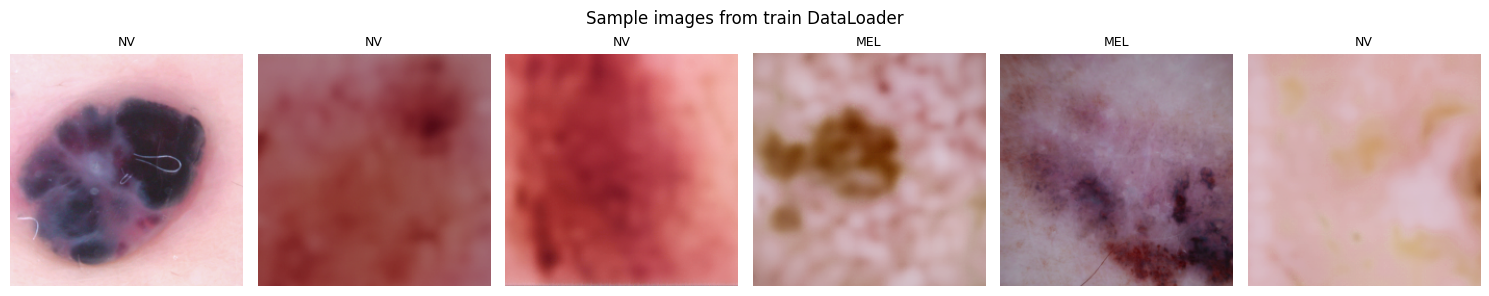

In [ ]:
# ── Sanity check: visualise a batch ──────────────────────────────────────────
batch = next(iter(train_loader))
sample_imgs     = batch["image"]
sample_labels   = batch["label"]
print("Batch shape :", sample_imgs.shape)
print("Labels (raw):", sample_labels[:8].tolist())

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
for i, ax in enumerate(axes):
    img = sample_imgs[i].permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    cls = sample_labels[i].argmax().item()
    ax.imshow(img)
    ax.set_title(LABEL_NAMES[cls], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample images from train DataLoader", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
model = NVMELClassifier(freeze_up_to=0).to(DEVICE)

frozen   = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Frozen parameters   : {frozen:,}")
print(f"Trainable parameters: {trainable:,}")

Frozen parameters   : 0
Trainable parameters: 4,008,829


In [ ]:
# ── Loss / optimiser / scheduler + auto-resume ────────────────────────────────
criterion = nn.BCEWithLogitsLoss()
# Only pass parameters that require gradients to the optimiser
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

# ── History buffers ───────────────────────────────────────────────────────────
start_epoch = 1
history     = defaultdict(list)

# ── Resume from latest checkpoint if one exists ───────────────────────────────
existing = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pth")))
if existing:
    latest = existing[-1]
    ckpt   = torch.load(latest, map_location=DEVICE, weights_only=False)

    start_epoch = ckpt["epoch"] + 1
    history     = ckpt["history"]
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optim_state"])
    scheduler.load_state_dict(ckpt["sched_state"])

    print(f"Resumed from '{latest}' (epoch {ckpt['epoch']} of {NUM_EPOCHS})")
else:
    print("No checkpoint found – starting from scratch.")

if start_epoch > NUM_EPOCHS:
    print(f"Training already complete ({NUM_EPOCHS} epochs done). Nothing to do.")

Resumed from 'checkpoints/efficientnet_nv_mel_classifier_recon_ms_ssim/epoch_050.pth' (epoch 50 of 50)
Training already complete (50 epochs done). Nothing to do.


In [ ]:
# ── Training loop (checkpoints every epoch) ───────────────────────────────────
for epoch in range(start_epoch, NUM_EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    total        = 0

    pbar = tqdm(train_loader, desc=f"Epoch [{epoch:>3}/{NUM_EPOCHS}] train", leave=False)
    for batch in pbar:
        imgs          = batch["image"].to(DEVICE, non_blocking=True)
        labels_onehot = batch["label"].to(DEVICE, non_blocking=True)
        labels        = labels_onehot.argmax(dim=1).float()

        # Apply aggressive label smoothing
        smoothed_labels = labels * (1.0 - LABEL_SMOOTHING) + 0.5 * LABEL_SMOOTHING

        logits = model(imgs).squeeze(-1)
        loss   = criterion(logits, smoothed_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        total        += imgs.size(0)
        pbar.set_postfix(loss=f"{running_loss / total:.4f}")

    train_loss = running_loss / total
    history["train_losses"].append(train_loss)

    # ── Validate ──────────────────────────────────────────────────────────────
    def _run_val(loader, tag):
        """Run one validation pass; return (loss, auc, acc, prec, rec, f1, cm)."""
        running_loss = 0.0
        total        = 0
        logits_list  = []
        targets_list = []

        with torch.no_grad():
            for batch in tqdm(loader, desc=f"Epoch [{epoch:>3}/{NUM_EPOCHS}] val-{tag}", leave=False):
                imgs          = batch["image"].to(DEVICE, non_blocking=True)
                labels_onehot = batch["label"].to(DEVICE, non_blocking=True)
                labels        = labels_onehot.argmax(dim=1)

                logits = model(imgs).squeeze(-1)
                loss   = criterion(logits, labels.float())
                running_loss += loss.item() * imgs.size(0)
                total        += imgs.size(0)

                logits_list.extend(logits.cpu().numpy())
                targets_list.extend(labels.cpu().numpy())

        loss_val = running_loss / total
        preds    = (np.array(logits_list) > 0).astype(int)
        auc      = roc_auc_score(targets_list, logits_list)
        acc      = accuracy_score(targets_list, preds)
        prec     = precision_score(targets_list, preds, zero_division=0)
        rec      = recall_score(targets_list, preds, zero_division=0)
        f1       = f1_score(targets_list, preds, zero_division=0)
        cm       = confusion_matrix(targets_list, preds)
        return loss_val, auc, acc, prec, rec, f1, cm

    model.eval()
    orig_loss,  orig_auc,  orig_acc,  orig_prec,  orig_rec,  orig_f1,  orig_cm  = _run_val(val_orig_loader,  "orig")
    recon_loss, recon_auc, recon_acc, recon_prec, recon_rec, recon_f1, recon_cm = _run_val(val_recon_loader, "recon")

    # averaged loss for the LR scheduler
    val_loss = (orig_loss + recon_loss) / 2

    history["val_orig_losses"].append(orig_loss)
    history["val_orig_aucs"].append(orig_auc)
    history["val_orig_accuracies"].append(orig_acc)
    history["val_orig_precisions"].append(orig_prec)
    history["val_orig_recalls"].append(orig_rec)
    history["val_orig_f1s"].append(orig_f1)
    history["val_orig_conf_matrices"].append(orig_cm)

    history["val_recon_losses"].append(recon_loss)
    history["val_recon_aucs"].append(recon_auc)
    history["val_recon_accuracies"].append(recon_acc)
    history["val_recon_precisions"].append(recon_prec)
    history["val_recon_recalls"].append(recon_rec)
    history["val_recon_f1s"].append(recon_f1)
    history["val_recon_conf_matrices"].append(recon_cm)

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch:>3}/{NUM_EPOCHS}]\n"
        f"  Train Loss  : {train_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}\n"
        f"  [orig ] Loss: {orig_loss:.4f}  | AUC: {orig_auc:.4f}  | Acc: {orig_acc:.4f}  | Prec: {orig_prec:.4f}  | Rec: {orig_rec:.4f}  | F1: {orig_f1:.4f}\n"
        f"  [orig ] CM:\n{orig_cm}\n"
        f"  [recon] Loss: {recon_loss:.4f}  | AUC: {recon_auc:.4f}  | Acc: {recon_acc:.4f}  | Prec: {recon_prec:.4f}  | Rec: {recon_rec:.4f}  | F1: {recon_f1:.4f}\n"
        f"  [recon] CM:\n{recon_cm}"
    )

    # ── Save per-epoch checkpoint ──────────────────────────────────────────────
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch:03d}.pth")
    torch.save({
        "epoch"         : epoch,
        "history"       : history,
        "model_state"   : model.state_dict(),
        "optim_state"   : optimizer.state_dict(),
        "sched_state"   : scheduler.state_dict(),
    }, ckpt_path)
    print(f"  └─ Checkpoint saved: {ckpt_path}")

print("\nTraining complete.")


Training complete.


In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
legacy_run_epochs = len(history["val_losses"])
history["train_losses"] = history["train_losses"][legacy_run_epochs:]

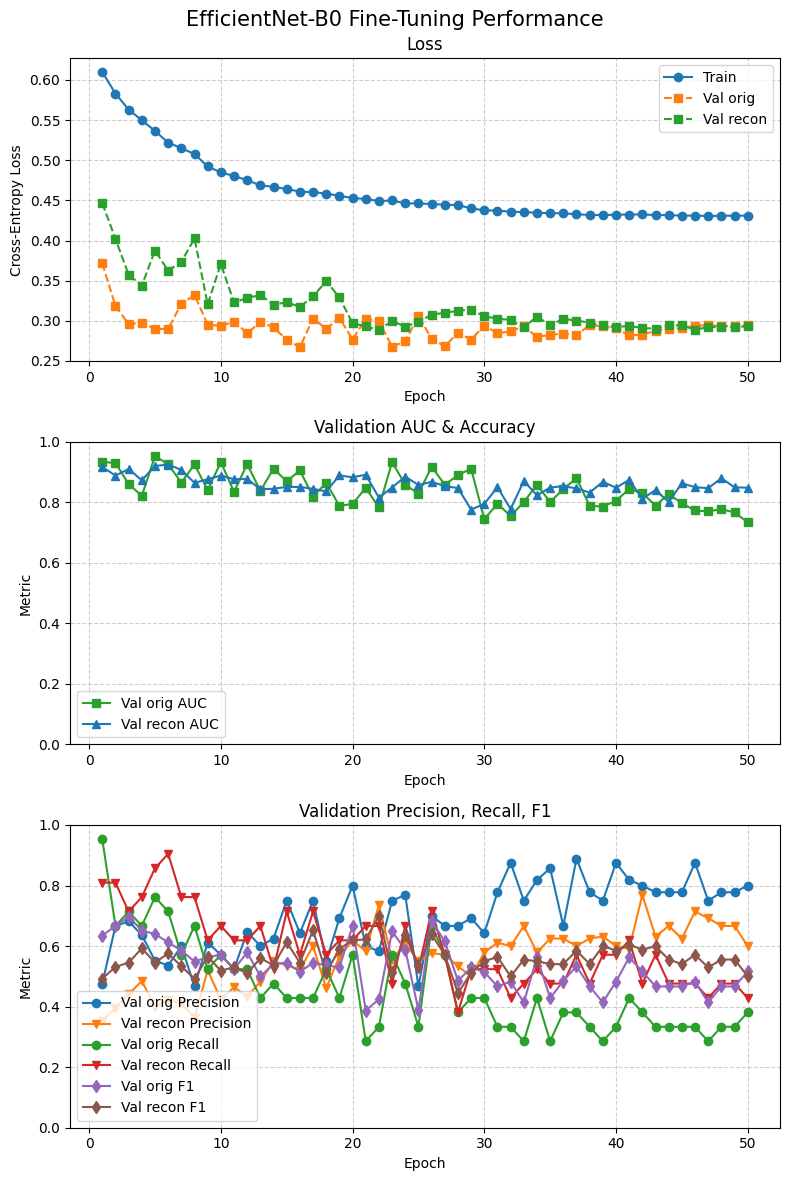

In [ ]:
n_recorded = len(history["train_losses"])
epochs_x   = range(1, n_recorded + 1)

# Use subplots to create a 3x1 grid. Added figsize to give the plots vertical space.
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 12))

# 1. Loss
ax1.plot(epochs_x, history["train_losses"], marker="o", linewidth=1.5, label="Train")
ax1.plot(epochs_x, history["val_orig_losses"],   marker="s", linewidth=1.5, label="Val orig", linestyle="--")
ax1.plot(epochs_x, history["val_recon_losses"],   marker="s", linewidth=1.5, label="Val recon", linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)

# 2. AUC & Accuracy
ax2.plot(epochs_x, history["val_orig_aucs"], marker="s", linewidth=1.5, color="tab:green", label="Val orig AUC")
ax2.plot(epochs_x, history["val_recon_aucs"], marker="^", linewidth=1.5, color="tab:blue", label="Val recon AUC")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Metric")
ax2.set_ylim(0, 1)
ax2.set_title("Validation AUC & Accuracy")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.6)

# 3. Precision, Recall, F1
# Fixed labels to separate 'orig' and 'recon' metrics
ax3.plot(epochs_x, history["val_orig_precisions"], marker="o", linewidth=1.5, label="Val orig Precision")
ax3.plot(epochs_x, history["val_recon_precisions"], marker="v", linewidth=1.5, label="Val recon Precision")
ax3.plot(epochs_x, history["val_orig_recalls"], marker="o", linewidth=1.5, label="Val orig Recall")
ax3.plot(epochs_x, history["val_recon_recalls"], marker="v", linewidth=1.5, label="Val recon Recall")
ax3.plot(epochs_x, history["val_orig_f1s"], marker="d", linewidth=1.5, label="Val orig F1")
ax3.plot(epochs_x, history["val_recon_f1s"], marker="d", linewidth=1.5, label="Val recon F1")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Metric")
ax3.set_ylim(0, 1)
ax3.set_title("Validation Precision, Recall, F1")
ax3.legend()
ax3.grid(True, linestyle="--", alpha=0.6)

plt.suptitle("EfficientNet-B0 Fine-Tuning Performance", fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
# ── Collect Activation Distributions ─────────────────────────────────────────
existing = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pth")))[10:30]
all_probs = []
ckpts = []

if existing:
    model.eval()
    with torch.no_grad():
        for ckpt_path in existing:
            ckpt_num = int(os.path.basename(ckpt_path).split('_')[1].split('.')[0])
            ckpts.append(ckpt_num)
            
            # Load checkpoint
            ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
            model.load_state_dict(ckpt["model_state"])
            
            ckpt_probs = []
            batch_idx = 0
            for batch in tqdm(val_recon_loader, desc=f"Checkpoint {ckpt_num:03d}", leave=False):
                if batch_idx >= 10: # ONLY FIRST 10 FOR NOW!!!
                    break

                images = batch["image"].to(DEVICE)
                outputs = model(images)
                # Get sigmoid probabilities
                probs = torch.sigmoid(outputs).cpu().numpy()
                ckpt_probs.extend(probs.flatten())

                batch_idx += 1
            
            all_probs.append(ckpt_probs)
    print(f"Collected distributions for {len(all_probs)} checkpoints.")
else:
    print("No checkpoints found in " + CHECKPOINT_DIR)

Collected distributions for 20 checkpoints.


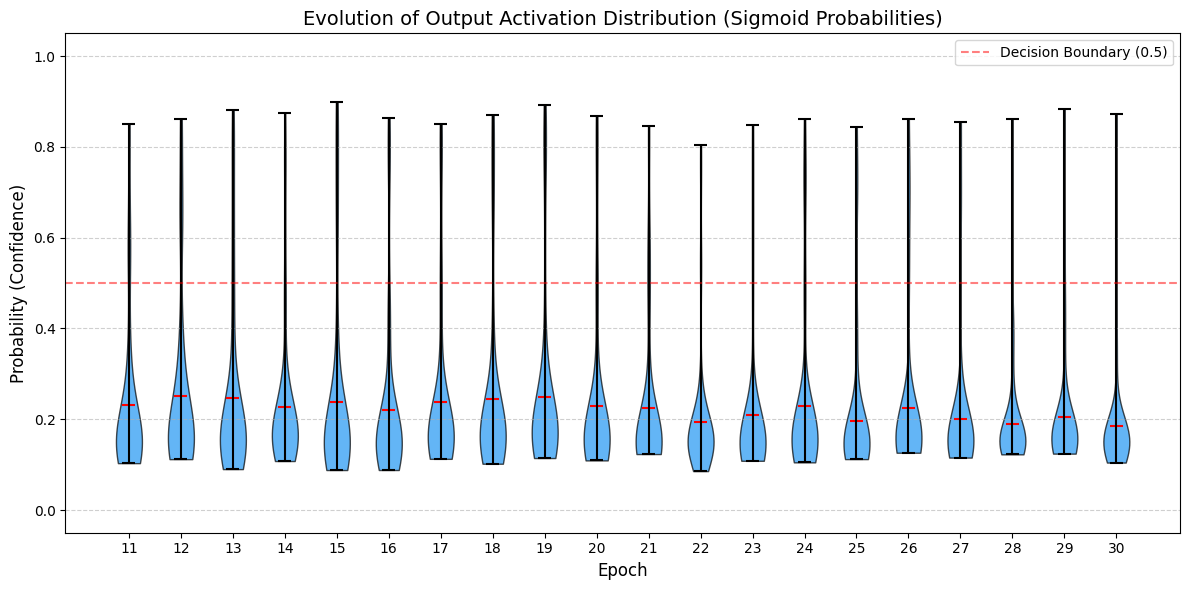

In [ ]:
# ── Plot Distributions ────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))

# Create violin plot
parts = plt.violinplot(all_probs, positions=ckpts, showmeans=True, showmedians=False)

# Customize aesthetics
for pc in parts['bodies']:
    pc.set_facecolor('#2196F3')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

parts['cbars'].set_edgecolor('black')
parts['cmaxes'].set_edgecolor('black')
parts['cmins'].set_edgecolor('black')
parts['cmeans'].set_edgecolor('red')

plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Decision Boundary (0.5)')

plt.title("Evolution of Output Activation Distribution (Sigmoid Probabilities)", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Probability (Confidence)", fontsize=12)
plt.xticks(ckpts)
plt.ylim(-0.05, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

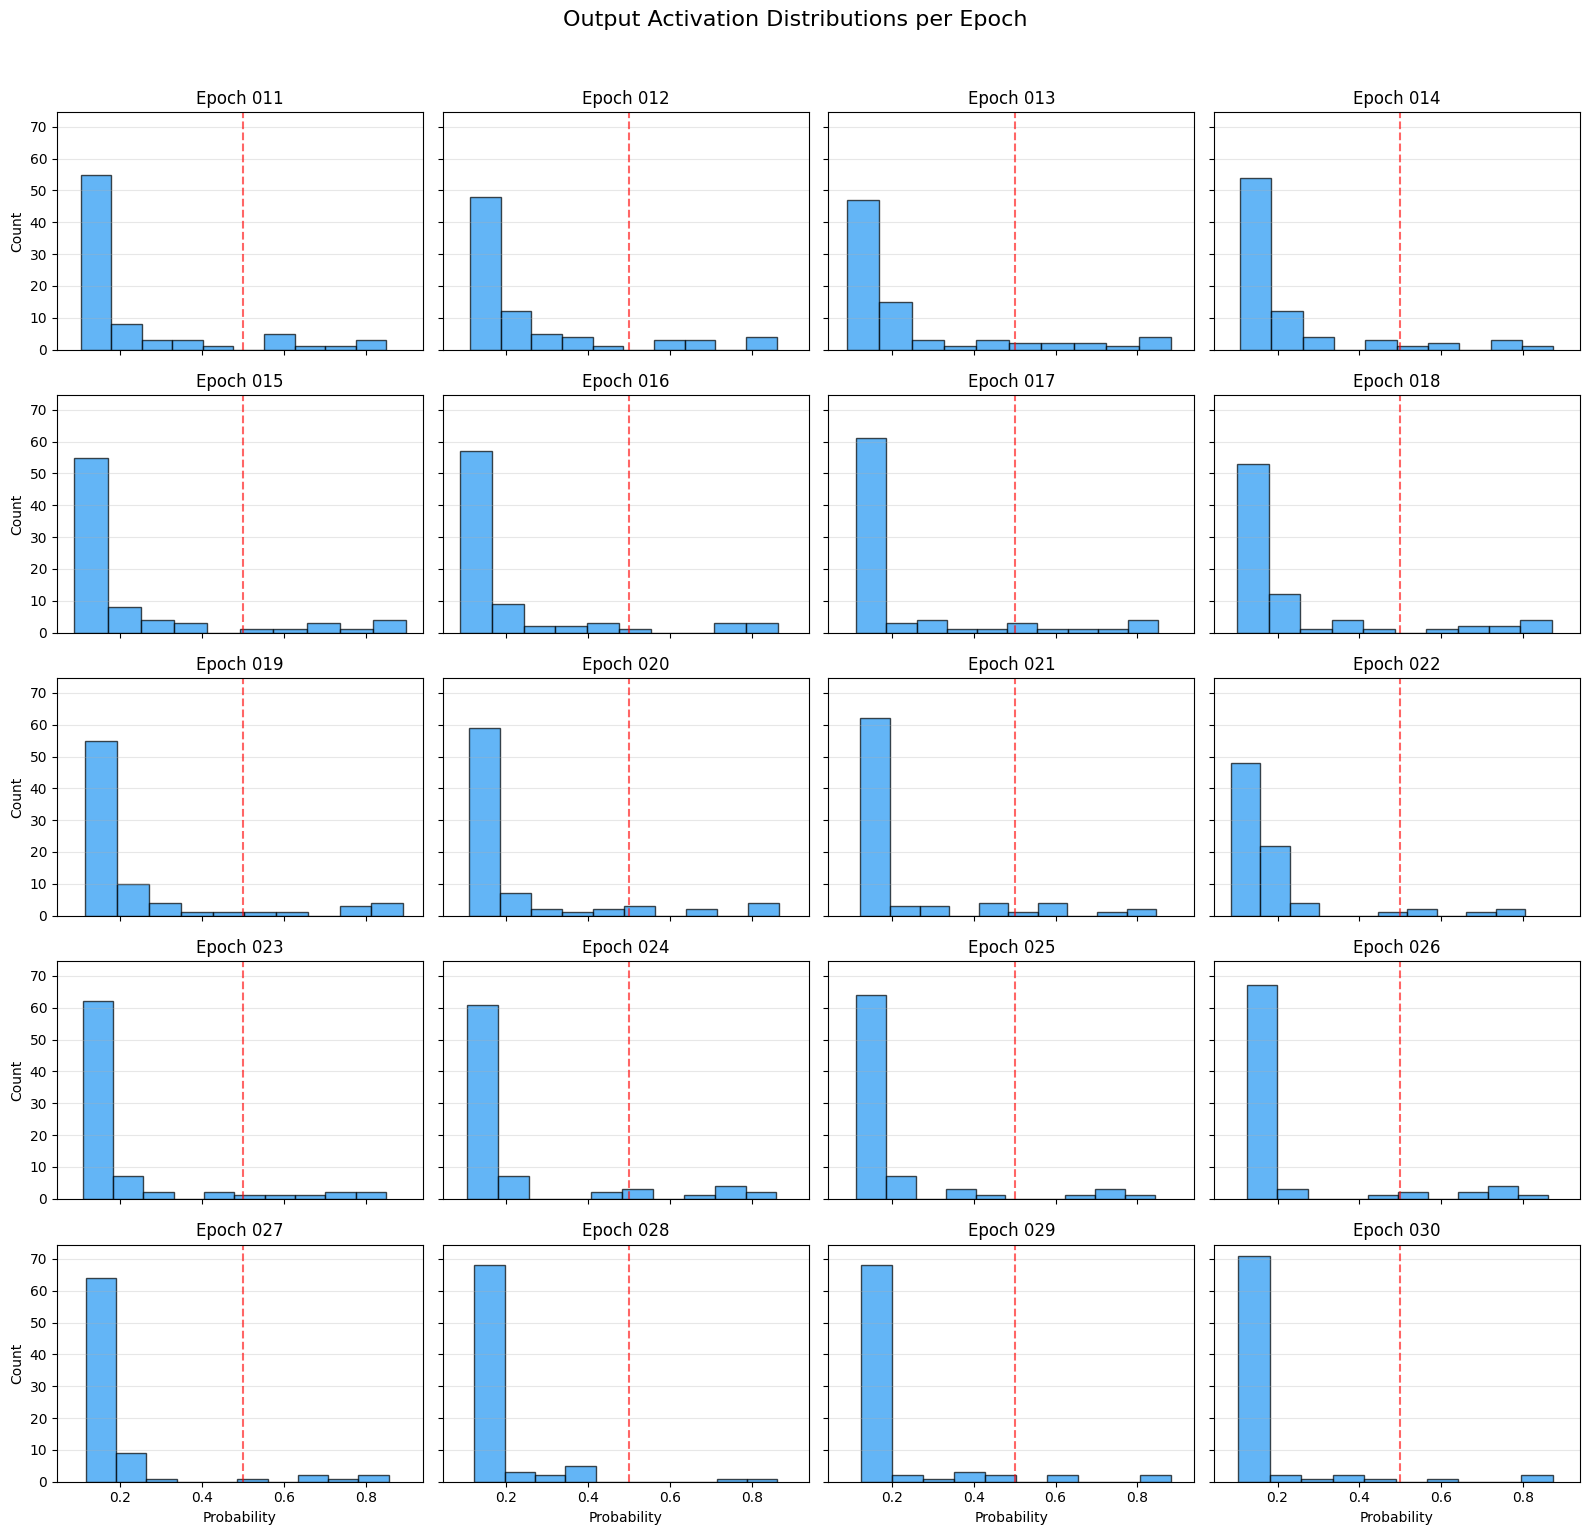

In [ ]:
# ── Plot Distributions (Histograms) ──────────────────────────────────────────
if all_probs:
    n_ckpts = len(all_probs)
    cols = 4
    rows = math.ceil(n_ckpts / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows), sharex=True, sharey=True)
    axes = axes.flatten()
    
    for i, (probs, epoch) in enumerate(zip(all_probs, ckpts)):
        ax = axes[i]
        ax.hist(probs, bins=10, color='#2196F3', alpha=0.7, edgecolor='black')
        ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.6)
        ax.set_title(f"Epoch {epoch:03d}")
        ax.grid(axis='y', alpha=0.3)
        
        if i >= (rows - 1) * cols:
            ax.set_xlabel("Probability")
        if i % cols == 0:
            ax.set_ylabel("Count")

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.suptitle("Output Activation Distributions per Epoch", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")